# LOAD THE DATA

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
loan_details = pd.read_csv("/content/credit_risk_dataset.csv")

# PERFORMING INITIAL ANALYSIS

In [3]:
loan_details

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
loan_details.shape

(32581, 12)

In [5]:
loan_details.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
loan_details.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
loan_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
loan_details.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [9]:
loan_details.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [10]:
loan_details.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# DATA CLEANING

## Person Age

In [11]:
loan_details['person_age'].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67])

In [12]:
print(loan_details['person_age'].dtype)

int64


In [13]:
loan_details.loc[loan_details['person_age'] >= 100,'person_age'].fillna(np.nan)

,person_age
81,144
183,144
575,123
747,123
32297,144


In [14]:
loan_details.loc[loan_details['person_age'] >= 100,'person_age']= np.nan

In [15]:
loan_details[loan_details['person_age'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,NaN,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,NaN,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,NaN,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,NaN,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,NaN,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [16]:
loan_details.loc[loan_details['person_age'].isna(),['person_income','person_emp_length']]

,person_income,person_emp_length
81,250000,4.0
183,200000,4.0
575,80004,2.0
747,78000,7.0
32297,6000000,12.0


In [17]:
loan_details.loc[81,'person_age'] = 26
loan_details.loc[183,'person_age'] = 27
loan_details.loc[575,'person_age'] = 24
loan_details.loc[747,'person_age'] = 29
loan_details.loc[32297,'person_age'] = 36

### **Ages above 100 were treated as invalid values. Since only 5 records were affected, ages were imputed manually using employment length and income as supporting features rather than using a global mean/median.**

## Loan interest

### **Since the loan_int_rate is only calculated after approving the loan,the loan_int_rate is dropped**

In [18]:
loan_details.drop('loan_int_rate', axis = 1,inplace = True)

## Person Employment length

In [19]:
loan_details[loan_details['person_emp_length']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000,RENT,123.0,PERSONAL,D,35000,1,0.59,Y,3
210,21.0,192000,MORTGAGE,123.0,VENTURE,A,20000,0,0.10,N,4


In [20]:
loan_details.loc[0,'person_emp_length'] = 1
loan_details.loc[210,'person_emp_length'] = 0

In [21]:
loan_details[loan_details['person_emp_length'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22.0,12600,MORTGAGE,NaN,PERSONAL,A,2000,1,0.16,N,4
222,24.0,185000,MORTGAGE,NaN,EDUCATION,B,35000,0,0.19,N,2
379,24.0,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,1,0.23,N,3
407,25.0,52000,RENT,NaN,PERSONAL,B,24000,1,0.46,N,2
408,22.0,17352,MORTGAGE,NaN,EDUCATION,C,2250,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...
32285,38.0,12000,OWN,NaN,EDUCATION,A,4800,1,0.40,N,12
32328,51.0,18408,RENT,NaN,PERSONAL,C,1000,1,0.05,Y,20
32360,70.0,39996,RENT,NaN,MEDICAL,C,3600,0,0.09,Y,19
32453,56.0,32400,RENT,NaN,MEDICAL,A,8575,0,0.26,N,18


In [22]:
loan_details['person_emp_length'] = loan_details['person_emp_length'].fillna(loan_details['person_emp_length'].median())

In [23]:
loan_details.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_status,0
loan_percent_income,0
cb_person_default_on_file,0


### **Invalid employment length values (>100 years) were treated as missing values. Since the column contained 895 missing observations, median imputation was used to replace missing employment length values.**

# DATA VISUALISATION

Text(0.5, 1.0, 'Age Distribution')

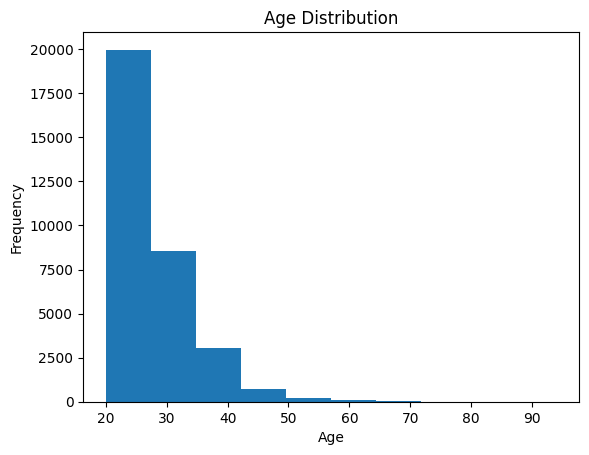

In [24]:
plt.hist(loan_details['person_age'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

<Axes: xlabel='person_home_ownership', ylabel='count'>

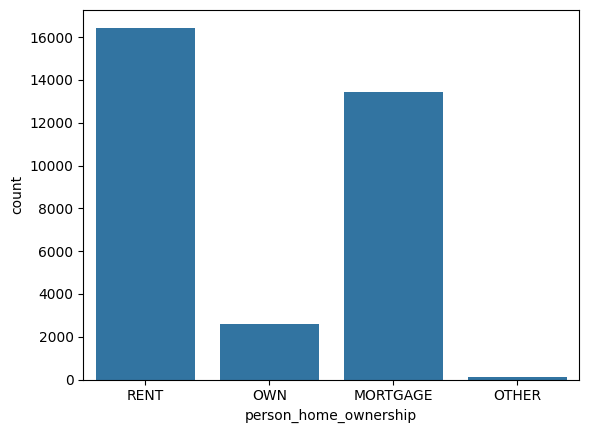

In [25]:
sns.countplot(x='person_home_ownership', data = loan_details)

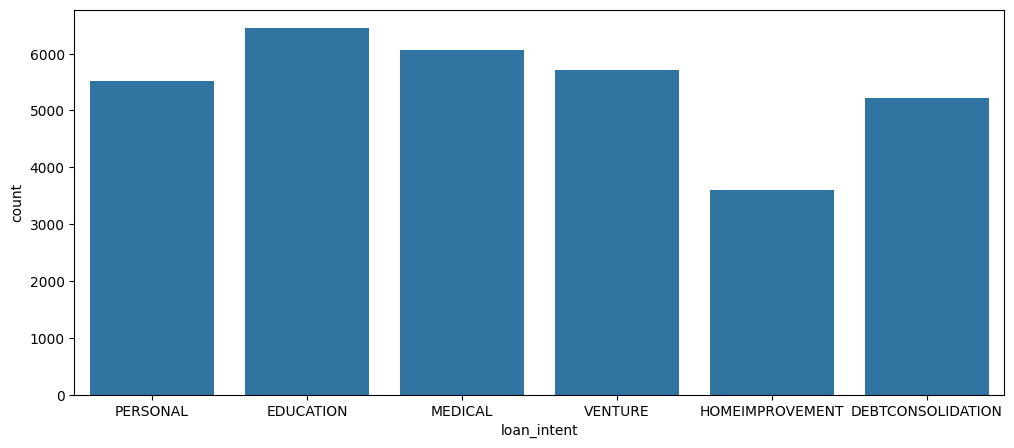

In [26]:
plt.figure(figsize=(12,5))
sns.countplot(x='loan_intent', data = loan_details)
plt.show()

### **loan_status is the target variable indicating whether a borrower defaulted on the loan. A value of 1 represents a default, while 0 represents successful repayment.**

Text(0.5, 1.0, 'Loan Status')

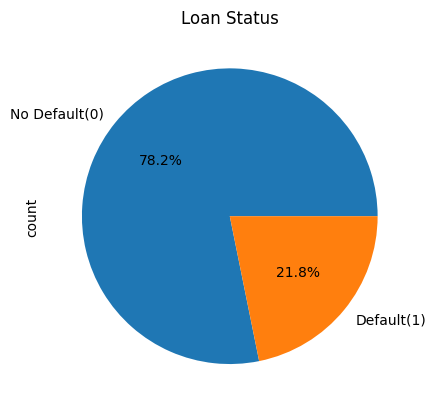

In [27]:
loan_details['loan_status'].value_counts().plot(kind = 'pie',labels = ['No Default(0)','Default(1)'],autopct = '%1.1f%%')
plt.title("Loan Status")


Text(0.5, 1.0, 'Previous Loan Default History')

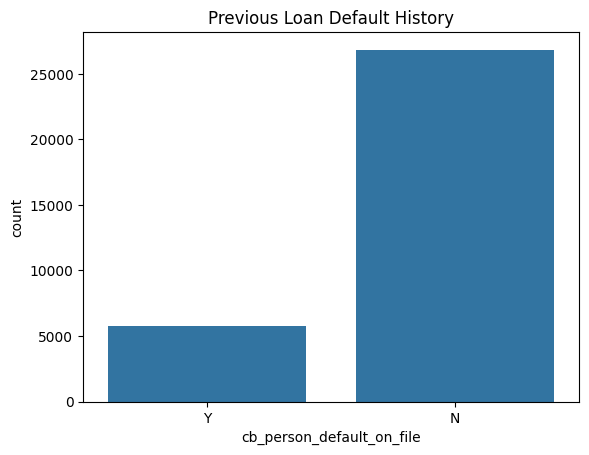

In [28]:
sns.countplot(x= 'cb_person_default_on_file',data = loan_details)
plt.title('Previous Loan Default History')

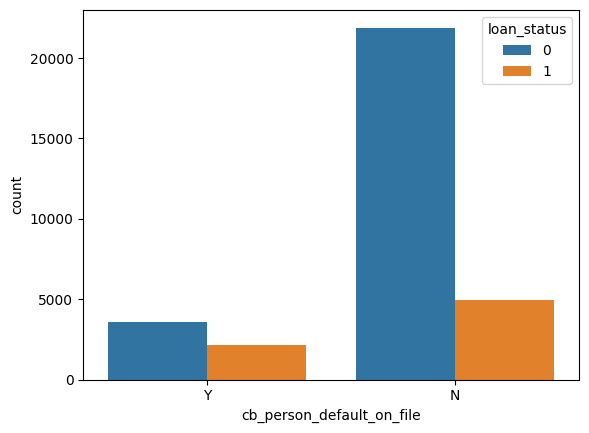

In [29]:
sns.countplot(data = loan_details,x = 'cb_person_default_on_file',hue = 'loan_status')
plt.show()

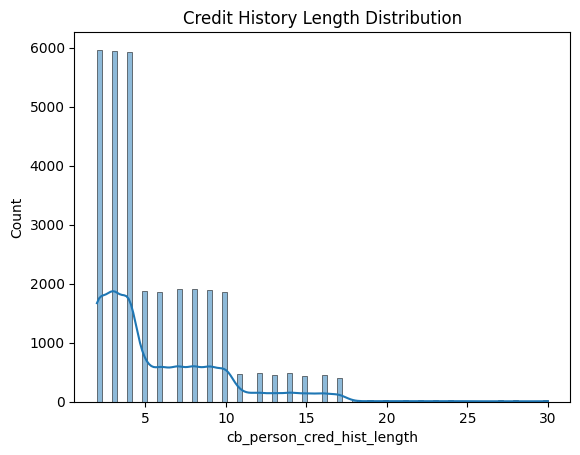

In [30]:
sns.histplot(
    loan_details['cb_person_cred_hist_length'],
    kde=True
)
plt.title('Credit History Length Distribution')
plt.show()

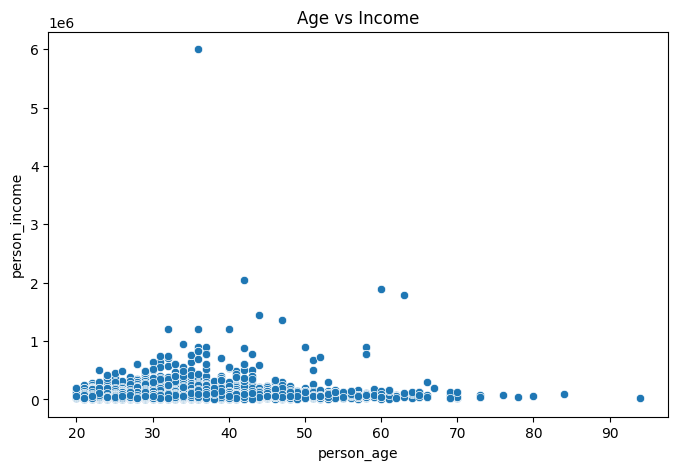

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=loan_details,
    x='person_age',
    y='person_income'
)
plt.title('Age vs Income')
plt.show()

# MODEL BUILDING

In [32]:
loan_details

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000,RENT,1.0,PERSONAL,D,35000,1,0.59,Y,3
1,21.0,9600,OWN,5.0,EDUCATION,B,1000,0,0.10,N,2
2,25.0,9600,MORTGAGE,1.0,MEDICAL,C,5500,1,0.57,N,3
3,23.0,65500,RENT,4.0,MEDICAL,C,35000,1,0.53,N,2
4,24.0,54400,RENT,8.0,MEDICAL,C,35000,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,57.0,53000,MORTGAGE,1.0,PERSONAL,C,5800,0,0.11,N,30
32577,54.0,120000,MORTGAGE,4.0,PERSONAL,A,17625,0,0.15,N,19
32578,65.0,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,1,0.46,N,28
32579,56.0,150000,MORTGAGE,5.0,PERSONAL,B,15000,0,0.10,N,26


In [33]:
X = loan_details[["person_income","person_home_ownership","loan_intent","loan_amnt","cb_person_default_on_file"]]
y = loan_details["loan_status"]

In [34]:
loan_details['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [35]:
loan_details['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [36]:
loan_details['cb_person_default_on_file'].unique()

array(['Y', 'N'], dtype=object)

# MODEL TRAINING

### LOGISTIC ALGORITHM

In [87]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [88]:
le = LabelEncoder()
X["person_home_ownership"] = le.fit_transform(X["person_home_ownership"])
X["cb_person_default_on_file"] = le.fit_transform(X["cb_person_default_on_file"])
X["loan_intent"] = le.fit_transform(X["loan_intent"])
print(X)

       person_income  person_home_ownership  loan_intent  loan_amnt  \
0              59000                      3            4      35000   
1               9600                      2            1       1000   
2               9600                      0            3       5500   
3              65500                      3            3      35000   
4              54400                      3            3      35000   
...              ...                    ...          ...        ...   
32576          53000                      0            4       5800   
32577         120000                      0            4      17625   
32578          76000                      3            2      35000   
32579         150000                      0            4      15000   
32580          42000                      3            3       6475   

       cb_person_default_on_file  
0                              1  
1                              0  
2                              0  
3      

/tmp/ipykernel_1162/2818933601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["person_home_ownership"] = le.fit_transform(X["person_home_ownership"])
/tmp/ipykernel_1162/2818933601.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["cb_person_default_on_file"] = le.fit_transform(X["cb_person_default_on_file"])
/tmp/ipykernel_1162/2818933601.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [122]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20)

In [123]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [124]:
y_pred = logistic_model.predict(X_test)

In [125]:
print(y_pred)

[0 1 0 ... 0 0 0]


In [126]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8138714132269449

In [127]:
clf = classification_report(y_test,y_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5087
           1       0.71      0.26      0.38      1430

    accuracy                           0.81      6517
   macro avg       0.76      0.62      0.64      6517
weighted avg       0.80      0.81      0.78      6517



In [128]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison


,Actual,Predicted
15173,0,0
20723,0,1
24813,1,0
29654,0,0
32510,0,0
...,...,...
8855,0,0
11359,0,0
23891,0,0
12159,0,0


In [129]:
X_new = X_test.iloc[[10]]
prediction = logistic_model.predict(X_new)
if (prediction[0]==0):
  print("loan not approved")
else:
  print("Loan approved")

loan not approved


In [131]:
X_test.iloc[10]

,27107
person_income,123000
person_home_ownership,0
loan_intent,5
loan_amnt,13225
cb_person_default_on_file,1


In [132]:
y_test.iloc[10]

np.int64(0)

### DECISION TREE

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [100]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20)

In [103]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train,y_train)

DecisionTreeClassifier()

In [105]:
y_pred = tree_model.predict(X_test)
y_pred

array([1, 0, 1, ..., 1, 0, 1])

In [106]:
accuracy_score(y_test,y_pred)

0.8421052631578947

In [109]:
cln = classification_report(y_test,y_pred)
print(cln)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      5094
           1       0.64      0.63      0.64      1423

    accuracy                           0.84      6517
   macro avg       0.77      0.77      0.77      6517
weighted avg       0.84      0.84      0.84      6517



In [110]:
comapare = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comapare

,Actual,Predicted
17888,1,1
27788,0,0
356,1,1
24956,0,1
4773,1,0
...,...,...
21911,0,0
8678,0,0
13894,1,1
24493,0,0


In [111]:
X_new = X_test.iloc[[10]]
prediction = logistic_model.predict(X_new)
if (prediction[0]==0):
  print("loan not approved")
else:
  print("Loan approved")

loan not approved


In [115]:
X_test.iloc[10]

,18784
person_income,64548
person_home_ownership,3
loan_intent,4
loan_amnt,1000
cb_person_default_on_file,1


In [133]:
y_test.iloc[10]

np.int64(0)

#MODEL DEPLOYMENT

In [134]:
from pickle import dump

In [137]:
dump(tree_model,open('loan_approval.pkl','wb'))